## Regression using e1_nutrients

#### Imports
In addition to the common libraries, sklearn, matplotlib, pandas and pathlib, I am using sklearnex which accelerates/optimises sklearn with vectorisation and GPU usage

In [12]:
# Required imports (includes sklearnex for better performance)
import sklearnex
sklearnex.patch_sklearn()
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


#### Define filter outliers method
After displaying each nutrient per depth on a scatter graph it was possible to see grouping. After this I created a boxplot for each nutrient per depth, from this it was possible to see that outliers were outside of the interquatile range bands, so this was the filtering method I chose.

In [13]:
def filter_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df[column] = df[column].where((df[column] >= lower_bound) & (df[column] <= upper_bound), None)
    return df

#### Import data and split test/train with 20% test size
I read the nutrients file in with pandas so that the data is as a DataFrame which is useful for later processing. Then I split the data into an 80/20 train/test split with set random_state 42 to ensure consistent results

In [74]:
# Import data and split into train/test sets
df = pd.read_csv(Path("e1_nutrients.csv"))
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

#### Filter outliers using IQR per depth and nutrient
For filtering, I create a copy of the train data (to display filtering in graph vs unfiltered), then loop through each set of data per Depth. Then I create a copy of the data for that depth using a filter and for each column in that depth, run the filtering method and set the filtered data back to the original. This fills train_filtered with None values where outliers were, I then use dropna to remove rows with a None value to discard any sets of reading with an outlier.

Initially, I was filtering the target column NITRITE as well as the non_target columns, however this was incorrect and caused me to be chasing bad results in regression.

In [75]:
# Filter outliers using IQR for each depth and nutrient column (excluding "NITRITE" as it's the target)
non_target_columns = [col for col in train_df.columns if col != "NITRITE"]

train_filtered = train_df.copy()
for depth in train_filtered["Depth"].unique():
    mask = train_filtered["Depth"] == depth
    depth_subset = train_filtered.loc[mask].copy()
    for column in non_target_columns:
        depth_subset = filter_outliers(depth_subset, column)
    train_filtered.loc[mask] = depth_subset
train_clean = train_filtered.dropna()

#### Scale train and test using RobustScaler
After filtering and cleaning the train dataset, it is scaled using RobustScaler which scales, normalises, and centers using IQR. 2 scalers are needed, one for the input data (x axis, all columns bar NITRITE) and one for the target values (y axis, only NITRITE column).

The scalers are fit on the train data only, but used to transform both the train and the test data. This ensures the regressors cannot become indirectly aware of the test data.

In [76]:
# Scale features and target using RobustScaler
x_scaler = RobustScaler()
y_scaler = RobustScaler()
x_train = x_scaler.fit_transform(train_clean.drop(columns=["NITRITE"]))
y_train = y_scaler.fit_transform(train_clean[["NITRITE"]]).ravel()
x_test = x_scaler.transform(test_df.drop(columns=["NITRITE"]))
y_test = y_scaler.transform(test_df[["NITRITE"]]).ravel()

df_filtered = train_filtered
df_scaled = train_clean.copy().astype(float)
cols_to_scale = df_scaled.columns != "NITRITE"
df_scaled.loc[:, cols_to_scale] = x_train

#### Scatter graphs to display filtering and scaling
To confirm the filtering and scaling was successful, I plotted original vs filtered vs scaled and filtered. The scaled & filtered data is using a seperate axis as it is scaled and so would not line up with the corresponding depth while on the original axis.

The graphs show that NITRITE is untouched by filtering and scaling, and that each other nutrient correctly has outliers removed and has been scaled. 

Note: x axis has an offset for each dataset to better show the difference

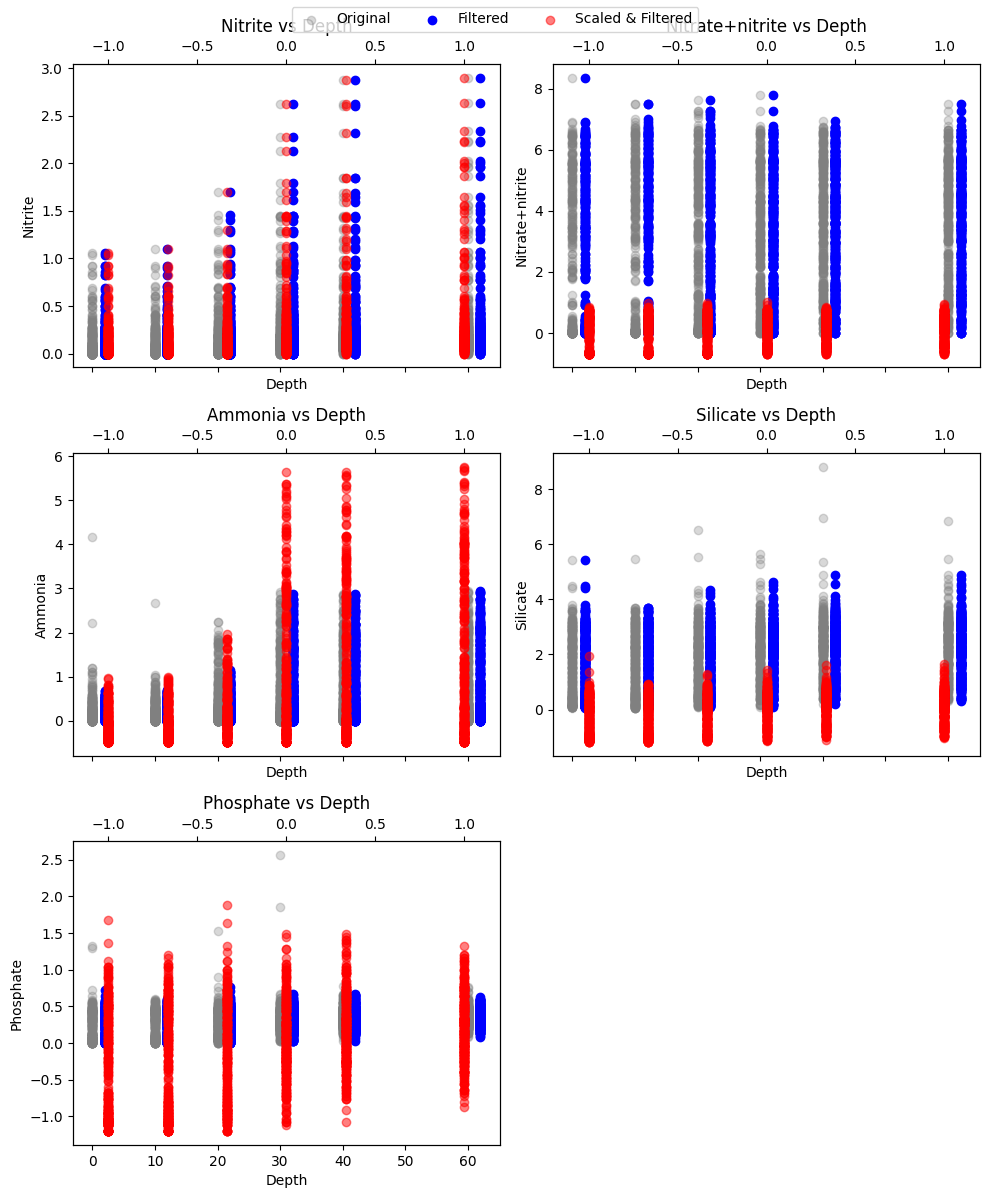

In [52]:
# Show filtering and scaling results of each chemical vs depth to ensure they are working
plot_columns = list(df.columns[1:])
fig, axes = plt.subplots(ncols=2, nrows=3, figsize=(10, 12), sharex=True)
axes = axes.flatten()

for i, column in enumerate(plot_columns):
    ax = axes[i]
    ax.scatter(train_df['Depth'], train_df[column], color="grey", alpha=0.3, label='Original')
    ax.scatter(df_filtered['Depth']+2, df_filtered[column], color="blue", label='Filtered')
    ax2 = ax.twiny()
    ax2.set_xlim(-1.2, 1.2)
    ax2.scatter(df_scaled['Depth'], df_scaled[column], color="red", alpha=0.5, label='Scaled & Filtered')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    ax.set_xlabel("Depth")
    ax.set_ylabel(column.capitalize())
    ax.set_title(f"{column.capitalize()} vs Depth")


handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles = handles1 + handles2
labels = labels1 + labels2
fig.legend(handles, labels, loc="upper center", ncol=3)
axes[-1].axis("off")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

#### RandomizedSearchCV for MLPRegressor hyperparameters
In order to tune the MLPRegressor's hyperparameters for the dataset, I am using RandomizedSearchCV with a varied parameter grid searching for the best parameter set scored on mean squared error. 

Previously I was using GridSearchCV, however, I switched to RandomizedSearch due to its faster speed as it doesn't evaluate every single option which was acceptable for my tuning. 

I ran the search many times trying many different possible parameter sets and found solutions which produced a better MSE but were much worse on cross validation due to overfitting. I continued to alter the parameter grid and removed some parameters from the grid completely such as solver and early_stopping as I found the defaults to be the best for this dataset.

Ultimately, the best parameters I found were `{'validation_fraction': 0.1, 'n_iter_no_change': 30, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (100,), 'alpha': 0.0005}`, however, there is very little improvement from the default parameters in this task.

In [ ]:
# Use randomized search to find the best hyperparameters for MLPRegressor with a validation set, then evaluate on the test set
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
mlp = MLPRegressor(max_iter=4000, random_state=42)
param_grid = [
    {
        'hidden_layer_sizes': [
            (100, 50),
            (100,),
            (100, 50, 25),
            (128, 64),
            (100, 100, 100),
        ],
        'alpha': [0.0005, 0.001],
        'learning_rate_init': [0.005, 0.001],
        'validation_fraction': [0.1],
        'n_iter_no_change': [30]
    }
]

grid_search = RandomizedSearchCV(estimator=mlp, param_distributions=param_grid, n_iter=200, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(x_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
test_preds = grid_search.best_estimator_.predict(x_test)
test_preds_unscaled = y_scaler.inverse_transform(test_preds.reshape(-1, 1)).ravel()
y_test_unscaled = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
print("MSE test (scaled):", mean_squared_error(y_test, test_preds))
print("MSE test (unscaled):", mean_squared_error(y_test_unscaled, test_preds_unscaled))
cv_results = grid_search.cv_results_
best_index = grid_search.best_index_
print(f"Best Train Score: {-cv_results['mean_train_score'][best_index]}")
print(f"Best Val Score: {-cv_results['mean_test_score'][best_index]}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/mdata/CS/comp2002/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 20 is smaller than n_iter=200. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END alpha=0.0005, hidden_layer_sizes=(100,), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   1.6s
[CV] END alpha=0.0005, hidden_layer_sizes=(100, 50), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   3.6s
[CV] END alpha=0.0005, hidden_layer_sizes=(100, 50), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   3.6s
[CV] END alpha=0.0005, hidden_layer_sizes=(100, 50), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   3.9s
[CV] END alpha=0.0005, hidden_layer_sizes=(100, 50), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   4.0s
[CV] END alpha=0.0005, hidden_layer_sizes=(100, 50), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   4.1s
[CV] END alpha=0.0005, hidden_layer_sizes=(100,), learning_rate_init=0.005, n_iter_no_change=30, validation_fraction=0.1; total time=   4.5

#### Find Best Hyperparams for RandomForest
Just like with MLPRegressor, I also used RandomizedSearchCV to tune the RandomForestRegressor's hyperparameters. This helped to slightly reduce overfitting of the train data, however I was unable to find much improvement just from hyperparamater tuning. 

The search works by picking a random set of parameters and applying them to the regressor and using cross validation to find the parameters which result in the lowest MSE.

I ran the search many times with a large variation of parameters and ended up removing some parameters from the grid such as `bootstrap` which I found the default to be the best option. 

Ultimately, the best paramaters I found were `'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}`

In [ ]:
# Use randomized search to find the best hyperparameters for RandomForestRegressor, then evaluate on the test set
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error

tree = RandomForestRegressor(random_state=42)
param_distributions = {
    'n_estimators': [100, 200, 500, 800, 1000],
    'max_depth': [None, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 3, 4, 6],
    'max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0],
}
grid_search_tree = RandomizedSearchCV(estimator=tree, param_distributions=param_distributions, n_iter=200, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error', return_train_score=True)
grid_search_tree.fit(x_train, y_train)
print("Best parameters found for Random Forest: ", grid_search_tree.best_params_)
test_preds_tree = grid_search_tree.best_estimator_.predict(x_test)
test_preds_tree_unscaled = y_scaler.inverse_transform(test_preds_tree.reshape(-1, 1)).ravel()

default_tree = RandomForestRegressor(random_state=42)
default_tree.fit(x_train, y_train)
default_test_preds_tree = default_tree.predict(x_test)
default_test_preds_tree_unscaled = y_scaler.inverse_transform(default_test_preds_tree.reshape(-1, 1)).ravel()
data = {
    "model": ["RandomForestRegressor-tuned", "RandomForestRegressor-default"],
    "test_scaled_mse": [mean_squared_error(y_test, test_preds_tree), mean_squared_error(y_test, default_test_preds_tree)],
    "test_unscaled_mse": [mean_squared_error(y_test_unscaled, test_preds_tree_unscaled), mean_squared_error(y_test_unscaled, default_test_preds_tree_unscaled)]
}
results_df = pd.DataFrame(data)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END max_depth=25, max_features=0.7, min_samples_leaf=2, min_samples_split=10, n_estimators=1000; total time=   0.7s
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=6, min_samples_split=5, n_estimators=1000; total time=   0.8s
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=3, min_samples_split=2, n_estimators=800; total time=   1.0s
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=6, min_samples_split=5, n_estimators=1000; total time=   0.9s
[CV] END max_depth=25, max_features=0.7, min_samples_leaf=2, min_samples_split=10, n_estimators=1000; total time=   0.8s
[CV] END max_depth=25, max_features=0.7, min_samples_leaf=2, min_samples_split=10, n_estimators=1000; total time=   0.8s
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=3, min_samples_split=2, n_estimators=800; total time=   1.0s
[CV] END max_depth=15, max_features=1.0, min_samples_leaf=3, min_samples_split=2, n_estimators=

#### Regressions

Each regressor is added to a list and evaluated with the test and train data to produce MSE, cross validation and R2 scores.

Commented out is functionality I added which produces an unscaled MSE which I used when comparing scalers to find the most optimimum scaler. This was needed as some scalers outputted a different range and therefore produced MSEs in a different range and were incomparable.

1. RandomForest default settings
2. RandomForest tuned with more estimators, and additional parameters from search
3. Linear regression
4. MLPRegressor default settings (increased max iterations)
5. MLPRegressor tuned with hyperparameters found from search

#### Outputs

1. R2 Test and Train
2. MSE Test and Train
3. Cross validation 

In [77]:
# Run regression models and compare results
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score

regressors = []
regressors.append(("RandomForestRegressor-default", RandomForestRegressor(random_state=42)))
regressors.append(("RF-Tuned", RandomForestRegressor(
    max_depth=30,
    max_features='log2',
    n_estimators=800, 
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
)))
regressors.append(("LinearRegression-default", LinearRegression()))
regressors.append(("MLPRegressor-default", MLPRegressor(random_state=42, max_iter=2000)))
# params from grid search with best cv mse
regressors.append(("MLPRegressor-tuned1", MLPRegressor(n_iter_no_change=30, max_iter=4000, hidden_layer_sizes=(100,), random_state=42, alpha=0.0005, learning_rate_init=0.001, validation_fraction=0.1)))


scores = []

for regressor_name, regressor in regressors:
    regressor.fit(x_train, y_train)
    train_preds = regressor.predict(x_train)
    test_preds = regressor.predict(x_test)
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    #test_preds_unscaled = y_scaler.inverse_transform(test_preds.reshape(-1, 1)).ravel()
    #y_test_unscaled = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
    #train_preds_unscaled = y_scaler.inverse_transform(train_preds.reshape(-1, 1)).ravel()
    #y_train_unscaled = y_scaler.inverse_transform(y_train.reshape(-1, 1)).ravel()

    test_scaled_mse = mean_squared_error(y_test, test_preds)
    #test_unscaled_mse = mean_squared_error(y_test_unscaled, test_preds_unscaled)

    train_scaled_mse = mean_squared_error(y_train, train_preds)
    #train_unscaled_mse = mean_squared_error(y_train_unscaled, train_preds_unscaled)

    cross_val = cross_val_score(regressor, x_train, y_train, cv=5, scoring='neg_mean_squared_error')

    scores.append((regressor_name, train_r2, test_r2, train_scaled_mse, test_scaled_mse, cross_val.mean(), cross_val.std())) #, train_unscaled_mse, test_unscaled_mse,

pd.DataFrame(scores, columns=["model", "train_r2", "test_r2", "train_scaled_mse", "test_scaled_mse", "cross_val_mean", "cross_val_std"]).sort_values("test_scaled_mse") # "train_unscaled_mse", "test_unscaled_mse", 

,model,train_r2,test_r2,train_scaled_mse,test_scaled_mse,cross_val_mean,cross_val_std
1,RF-Tuned,0.929991,0.562600,0.215710,1.197370,-1.616232,0.196466
0,RandomForestRegressor-default,0.930312,0.543669,0.214721,1.249192,-1.700626,0.156451
4,MLPRegressor-tuned1,0.572500,0.373311,1.317196,1.715541,-1.899782,0.169191
3,MLPRegressor-default,0.458773,0.336798,1.667608,1.815494,-1.905816,0.124032
2,LinearRegression-default,0.136676,0.089373,2.660041,2.492813,-2.672020,0.326600


#### Plot feature importance for random forest tuned regressor
To evaluate the performance of the tuned random forest regressor, I have plotted the feature importance for predicting nitrite. The graph shows that the most important feature found by the tree was the NITRATE+NITRITE feature which suggests the model may be too heavily relying on this value due to it being the sum of the target column and another data point. 

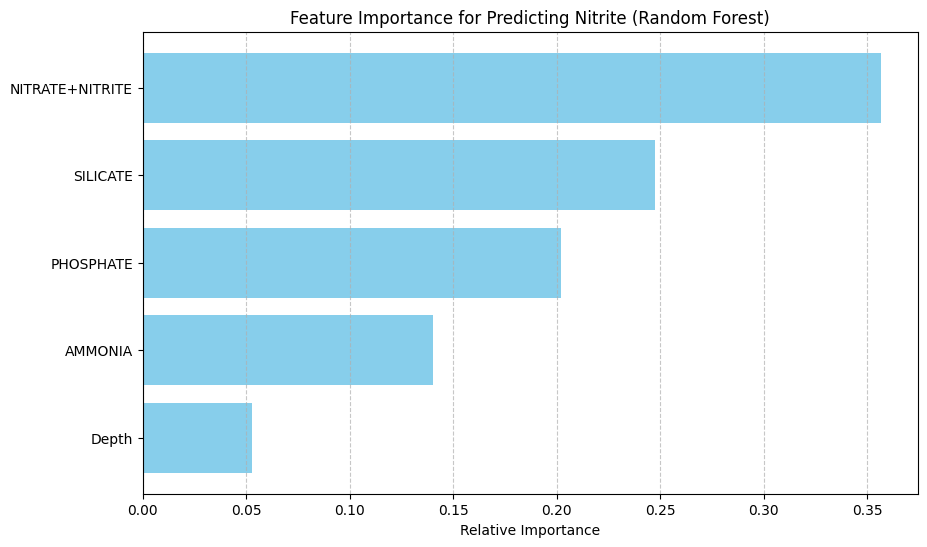

In [78]:
import numpy as np
feature_names = train_clean.drop(columns=["NITRITE"]).columns

rf_default = regressors[0][1]
importances = rf_default.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title("Feature Importance for Predicting Nitrite (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### Plot MSE per regressor
To finally evaluate the performance of each regressor on the dataset, I plot the MSE and Cross Val Mean of each regressor.

Looking at only MSE, it would appear that the tuned random forest model is the best for the dataset, however taking cross validation standard deviation into account, it is possible to see the model does not perform as well on all data and the default random forest model may be preferable as it is the second best for MSE and is more consistent than the tuned version. 

Interestingly, the tuned MLP regressor is also less consistent in cross validation than the default parameter model despite a slightly higher MSE. This shows that simply optimising for just MSE does not always produce a better model


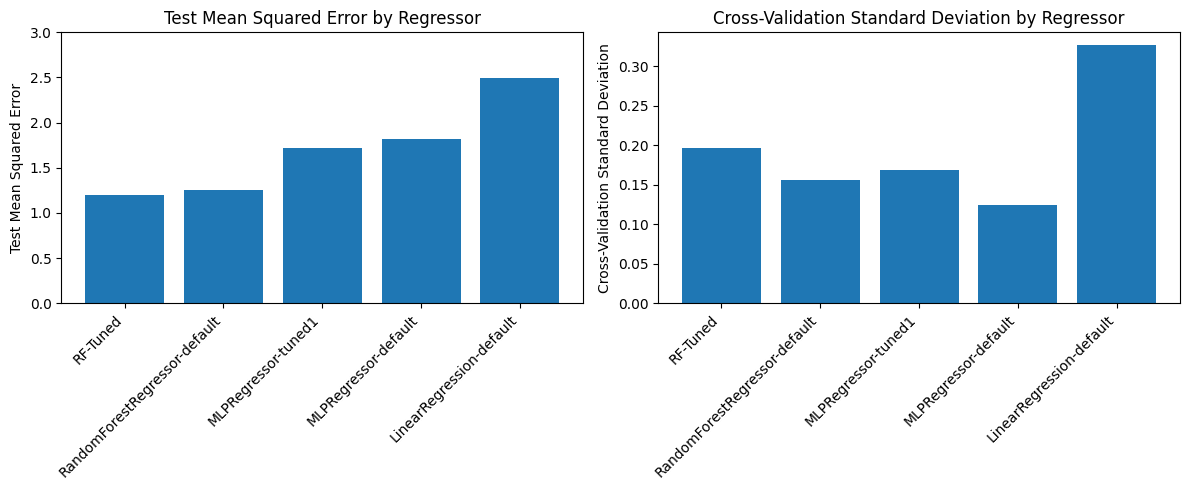

In [88]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
scores = sorted(scores, key=lambda x: x[4])  # Sort by test_unscaled_mse
regressor_names = [score[0] for score in scores]
cross_val_stds = [score[6] for score in scores]
ms_values = [score[4] for score in scores]

ax1.bar(range(len(regressor_names)), ms_values)
ax1.set_xticks(range(len(regressor_names)))
ax1.set_xticklabels(regressor_names, rotation=45, ha='right')
ax1.set_ylabel('Test Mean Squared Error')
ax1.set_title('Test Mean Squared Error by Regressor')
ax1.set_ylim(0, 3)

ax2.bar(range(len(regressor_names)), cross_val_stds)
ax2.set_xticks(range(len(regressor_names)))
ax2.set_xticklabels(regressor_names, rotation=45, ha='right')
ax2.set_ylabel('Cross-Validation Standard Deviation')
ax2.set_title('Cross-Validation Standard Deviation by Regressor')

plt.tight_layout()
plt.show()